# Results: the classics against the alternatives

The comparison this project exists to make. Every model is fitted on the 2020
cohort and scored on the 2021 cohort — strictly out of time, with all
preprocessing (winsorising cut-points, imputation medians, category levels,
quintile thresholds) learned inside the fitting pipeline so that nothing about
the test year leaks backwards.

Two expensive artefacts — the paired bootstrap and the permutation importances —
are read from `outputs/tables`, produced by `python -m charity_risk.pipeline`.
Everything else is computed here.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import average_precision_score, roc_auc_score

from charity_risk import config, plots
from charity_risk.dataset import load_dataset, exit_split, scoring_frame
from charity_risk.evaluate import (
    bootstrap_metric_difference, calibration_table, compare_models, fit_all,
    lift_table,
)
from charity_risk.models import SPECIFICATIONS

plots.use_project_style()
pd.set_option("display.width", 220)

columns = sorted({c for spec in SPECIFICATIONS.values() for c in spec.columns}) + [
    "exit_next_year", "legal_name", "total_revenue", "total_assets", "net_assets"]
frame = load_dataset(years=[config.TRAIN_YEAR, config.TEST_YEAR, config.SCORE_YEAR],
                     columns=columns)
train, test = exit_split(frame)

pd.DataFrame({
    "specification": {k: s.label for k, s in SPECIFICATIONS.items()},
    "source": {k: s.citation for k, s in SPECIFICATIONS.items()},
    "n_features": {k: len(s.columns) for k, s in SPECIFICATIONS.items()},
})

,specification,source,n_features
size_only,Size only (log revenue),Null benchmark: how much of the classics is ju...,1
tuckman_chang_1991,Tuckman-Chang score (0-4),Tuckman & Chang (1991),4
greenlee_trussel_2000,Greenlee-Trussel logit (4 TC ratios),Greenlee & Trussel (2000),4
trussel_2002,Trussel logit (ratios + size + sector),Trussel (2002),6
extended_logit,Elastic-net logit (extended),This project,51
gradient_boosting,Gradient boosting (extended),This project,51
deep_neural_net,Deep neural net (extended),"Alam, Gao & Jones (2021)",51
ensemble_blend,Model-average ensemble (logit + GBM + net),Bates & Granger (1969); this project,51


## Model specifications, formally

Every model below has already had a prose treatment — in this notebook and in
`00-literature-review` / `02-features-and-benchmarks` / `06-hs-risk-index`. This
section adds the
formal statement each family corresponds to, for readers who want to know
exactly what estimator produced a number, followed by one plain-language line
for readers who do not need the equation. $x_i$ is charity $i$'s feature
vector; $y_i \in \{0,1\}$ is `exit_next_year`.

**Tuckman-Chang score.** Not a fitted model — a checklist:
$$S_i = \sum_{k=1}^{4} \mathbb{1}\!\left[r_{k,i} \text{ in the sector's risky quintile of ratio } k\right]$$
with each ratio's quintile cut-point estimated on the training sample and
applied unchanged. *In plain terms:* flag an organisation on a ratio if it
sits in the worst fifth of the sector on that ratio, and count the flags.

**HS risk index.** Also not a fitted model, and a separate index from the
Tuckman-Chang score: twelve ratios $k$ grouped into five dimensions $j$
(solvency, liquidity, profitability, efficiency, revenue),
$$s_{k,i} = \hat F_k(d_k\, r_{k,i}), \qquad D_{j,i} = \operatorname{mean}_{k \in j}\, s_{k,i}, \qquad I_i = \operatorname{mean}_{j}\, D_{j,i}$$
where $d_k = \pm 1$ orients ratio $k$ so that larger is riskier, $\hat F_k$ is
its empirical CDF in the training sample, and each mean runs over the ratios
and dimensions observed for charity $i$. The flag form replaces $s_{k,i}$ with
an indicator for the ratio's riskiest fifth. A one-variable logit maps $I_i$ to
a probability so it can be scored on the same metrics; being monotone, it
changes no ranking. *In plain terms:* for each ratio, take the share of last
year's sector that looked safer; average those within each dimension, then
average the dimensions, so each of the five counts equally however many ratios
describe it. `06-hs-risk-index` builds and evaluates it in full.

**Greenlee-Trussel (2000), Trussel (2002), size-only, elastic-net logit.** All
four are the same functional form,
$$\Pr(y_i = 1 \mid x_i) = \sigma(\beta_0 + \beta^\top x_i), \qquad \sigma(z) = \frac{1}{1+e^{-z}}$$
differing only in which $x_i$ go in and how $\beta$ is estimated: maximum
likelihood for the first three (4, 6 and 1 predictors respectively), and
elastic-net-penalised maximum likelihood —
$\min_\beta -\ell(\beta) + \tfrac{1}{C}\left[\tfrac{1-\rho}{2}\lVert\beta\rVert_2^2 + \rho\lVert\beta\rVert_1\right]$
— for the 51-feature version, where the penalty keeps the fit stable on
correlated ratios an unpenalised fit would not handle. *In plain terms:* each
feature gets a weight, the weighted sum is squashed into a probability, and
the weights are chosen to make the observed exits as likely as possible.

**Gradient boosting.** An additive expansion of shallow decision trees, fitted
one at a time on the current model's error:
$$F_M(x) = \sum_{m=1}^{M} \nu\, h_m(x), \qquad h_m = \arg\min_h \sum_i \ell\bigl(y_i,\, F_{m-1}(x_i) + h(x_i)\bigr)$$
*In plain terms:* a sequence of simple decision rules, each correcting what
the rules before it got wrong, added together into a score. Every split is a
threshold test on one feature, so — unlike the logits above — it can find a
breakpoint (interest coverage below 1x, say) without being told where to look.

**Deep neural net.** A composition of affine transformations and a fixed
nonlinearity $\phi$ (ReLU), three hidden layers wide,
$$\hat p_i = \sigma\bigl(W_4\,\phi(W_3\,\phi(W_2\,\phi(W_1 x_i + b_1) + b_2) + b_3) + b_4\bigr)$$
fitted jointly by minimising binomial cross-entropy with Adam. *In plain
terms:* the same logistic-regression idea, but the weighted sum passes through
several rounds of learned, nonlinear recombination before becoming a
probability, so it can represent interactions the logit's single linear
combination cannot.

**Model-average ensemble.** No new functional form — a forecast combination
({cite:t}`bates1969`) of the three models above it:
$$\hat p_i = \tfrac{1}{3}\bigl(\hat p_i^{\text{logit}} + \hat p_i^{\text{gbm}} + \hat p_i^{\text{mlp}}\bigr)$$
*In plain terms:* average the risk score three different modelling approaches
assign, on the logic that models making different kinds of mistakes partly
cancel each other's mistakes out when combined.

**Hierarchical logit.** Introduced separately, below, once the flat comparison
is done — see its own formal statement there.

In [2]:
fitted = fit_all(train, "exit_next_year")
results = compare_models(fitted, test, "exit_next_year")

headline = results[["label", "roc_auc", "average_precision", "brier_skill",
                    "lift_top1pct", "lift_top5pct", "recall_top5pct",
                    "calibration_slope"]]
headline.style.format({
    "roc_auc": "{:.3f}", "average_precision": "{:.3f}", "brier_skill": "{:.3f}",
    "lift_top1pct": "{:.1f}x", "lift_top5pct": "{:.1f}x",
    "recall_top5pct": "{:.1%}", "calibration_slope": "{:.2f}",
}).background_gradient(subset=["average_precision"], cmap="Blues")

extended_logit: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


gradient_boosting: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


deep_neural_net: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


ensemble_blend: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


,label,roc_auc,average_precision,brier_skill,lift_top1pct,lift_top5pct,recall_top5pct,calibration_slope
model,,,,,,,,
ensemble_blend,Model-average ensemble (logit + GBM + net),0.844,0.195,0.095,16.3x,8.2x,40.8%,0.95
gradient_boosting,Gradient boosting (extended),0.842,0.188,0.093,16.3x,8.1x,40.3%,0.80
deep_neural_net,Deep neural net (extended),0.828,0.174,0.083,14.8x,7.7x,38.6%,0.89
extended_logit,Elastic-net logit (extended),0.827,0.155,0.073,12.3x,7.6x,38.2%,0.88
trussel_2002,Trussel logit (ratios + size + sector),0.807,0.111,0.052,9.2x,7.1x,35.4%,0.91
greenlee_trussel_2000,Greenlee-Trussel logit (4 TC ratios),0.744,0.094,0.045,9.1x,6.7x,33.5%,0.96
size_only,Size only (log revenue),0.786,0.081,0.036,5.9x,5.6x,28.0%,0.97
tuckman_chang_1991,Tuckman-Chang score (0-4),0.587,0.032,0.006,4.2x,3.0x,14.9%,0.94


## How to read this table

The exit base rate is 2.0%, so accuracy is meaningless and ROC-AUC is
optimistic — it is dominated by the vast easy majority of true negatives. Two
columns carry the weight:

* **Average precision** — area under the precision-recall curve. At a 2% base
  rate a no-skill model scores 0.020.
* **Lift in the top 1% / 5%** — the honest operational number. A supervisor with
  the budget to review 5% of the register wants to know how many more failures
  that 5% contains than a random 5% would.

**Calibration slope** is reported separately because it answers a different
question. A slope below 1 means the score is over-dispersed: useful for ranking,
but the probabilities themselves should not be plugged into expected-loss
arithmetic without recalibration.

The table also carries both forms of the HS risk index, flags and percentile.
Their rows are read in detail in `06-hs-risk-index`, against the other
unfitted and lightly fitted benchmarks.

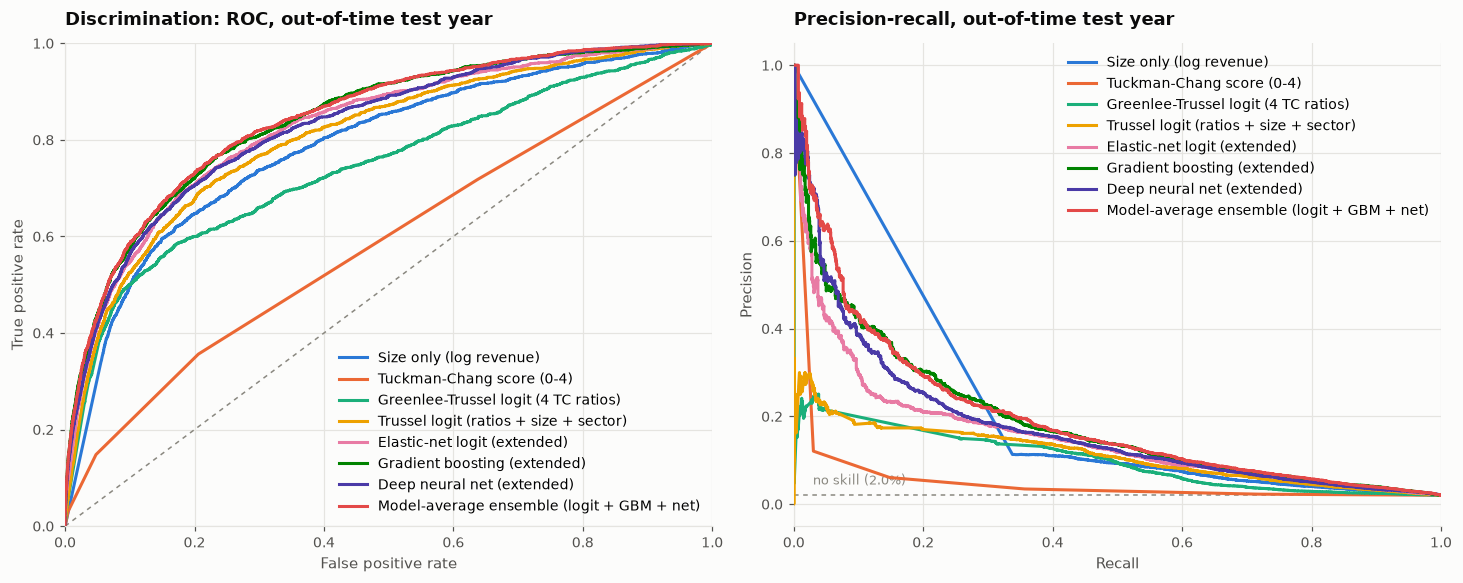

In [3]:
y_test = test["exit_next_year"].to_numpy()
risks = {model.spec.label: model.risk(test) for model in fitted.values()}

fig, axes = plots.plt.subplots(1, 2, figsize=(13.4, 5.4))
plots.plot_roc_curves(y_test, risks, ax=axes[0])
plots.plot_pr_curves(y_test, risks, ax=axes[1])
fig.tight_layout();

The two panels tell different stories, and the difference is the point.

On ROC, everything except the Tuckman-Chang count looks broadly similar — the
classics land within 0.10 of gradient boosting. On precision-recall, the
gradient-boosting curve holds a visible margin over the others across the whole
range a screening tool would operate in, and the two classical logits converge
toward the no-skill line well before gradient boosting does. ROC flatters models
on imbalanced problems; a supervisor choosing a screening tool on AUC alone would
materially over-value the classics.

The size-only baseline is the curiosity. Its precision-recall curve is a near
straight line falling from (0, 1.0): log revenue is a coarse, heavily-tied
ranking, so precision degrades linearly as the threshold sweeps down. It reaches
an AUC of 0.786 — higher than Greenlee-Trussel's 0.744 — on one variable.

## Screening yield

The chart to look at if the model will be used to allocate review capacity. The
x-axis is workload; the y-axis is what that workload catches.

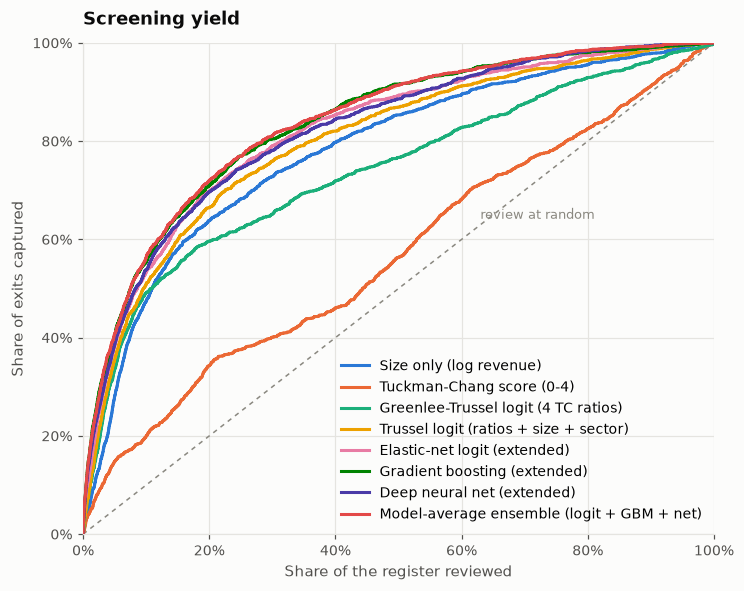

In [4]:
fig, ax = plots.plt.subplots(figsize=(7.4, 5.8))
plots.plot_gains_curves(y_test, risks, ax=ax);

In [5]:
budget = pd.DataFrame({
    label: {
        f"review {int(f*100)}% of register":
            float(np.sum(y_test[np.argsort(-risk, kind='mergesort')][:int(round(f * len(y_test)))]) / y_test.sum())
        for f in (0.01, 0.05, 0.10, 0.25)
    } for label, risk in risks.items()
}).T
budget.style.format("{:.1%}").background_gradient(cmap="Blues")

,review 1% of register,review 5% of register,review 10% of register,review 25% of register
Size only (log revenue),5.9%,28.0%,47.4%,68.3%
Tuckman-Chang score (0-4),4.3%,14.8%,20.0%,37.6%
Greenlee-Trussel logit (4 TC ratios),8.7%,33.4%,49.2%,62.3%
Trussel logit (ratios + size + sector),9.2%,35.4%,50.9%,72.0%
Elastic-net logit (extended),12.3%,38.2%,53.4%,74.8%
Gradient boosting (extended),16.3%,40.3%,55.4%,77.0%
Deep neural net (extended),14.8%,38.6%,53.8%,74.5%
Model-average ensemble (logit + GBM + net),16.3%,40.8%,56.3%,76.9%


Reviewing the highest-risk 5% of the register — about 4,200 organisations —
catches 40% of the following year's exits under gradient boosting, 35% under
Trussel (2002), 33% under Greenlee-Trussel, and 15% under the Tuckman-Chang
count. Against reviewing 5% at random, which catches 5%.

The same thing framed as workload — the share of the register you must review to
catch half of the exits:

In [6]:
def workload_for(risk, target=0.5):
    captured = np.cumsum(y_test[np.argsort(-risk, kind="mergesort")]) / y_test.sum()
    return float(np.argmax(captured >= target) + 1) / len(y_test)

pd.Series({label: workload_for(risk) for label, risk in risks.items()},
          name="share of register reviewed to capture 50% of exits").sort_values().to_frame().style.format("{:.1%}")

,share of register reviewed to capture 50% of exits
Model-average ensemble (logit + GBM + net),7.5%
Gradient boosting (extended),7.5%
Deep neural net (extended),8.3%
Elastic-net logit (extended),8.6%
Trussel logit (ratios + size + sector),9.6%
Greenlee-Trussel logit (4 TC ratios),10.7%
Size only (log revenue),10.9%
Tuckman-Chang score (0-4),44.3%


## Is the difference real?

Paired bootstrap of the AUC difference against the strongest classical
benchmark, Trussel (2002). Resampling is paired — the same resampled rows score
both models — so the interval reflects the difference rather than the sum of two
independent sampling errors.

In [7]:
bootstrap = pd.read_csv(config.TABLE_DIR / "exit_auc_vs_benchmark.csv", index_col=0)
bootstrap["95% interval"] = bootstrap.apply(
    lambda r: f"[{r['ci_low']:+.3f}, {r['ci_high']:+.3f}]", axis=1)
bootstrap[["label", "versus", "auc_difference", "95% interval", "p_worse"]].round(4)

,label,versus,auc_difference,95% interval,p_worse
model,,,,,
size_only,Size only (log revenue),Trussel logit (ratios + size + sector),-0.0214,"[-0.030, -0.014]",1.0
tuckman_chang_1991,Tuckman-Chang score (0-4),Trussel logit (ratios + size + sector),-0.2201,"[-0.237, -0.206]",1.0
greenlee_trussel_2000,Greenlee-Trussel logit (4 TC ratios),Trussel logit (ratios + size + sector),-0.0635,"[-0.072, -0.054]",1.0
extended_logit,Elastic-net logit (extended),Trussel logit (ratios + size + sector),0.0198,"[+0.015, +0.025]",0.0
gradient_boosting,Gradient boosting (extended),Trussel logit (ratios + size + sector),0.0348,"[+0.029, +0.041]",0.0
deep_neural_net,Deep neural net (extended),Trussel logit (ratios + size + sector),0.0213,"[+0.014, +0.029]",0.0
ensemble_blend,Model-average ensemble (logit + GBM + net),Trussel logit (ratios + size + sector),0.0371,"[+0.032, +0.043]",0.0


Gradient boosting and the elastic-net logit both beat Trussel (2002) with
intervals well clear of zero. Greenlee-Trussel (2000) and the Tuckman-Chang count
both lose to it decisively — the 2002 re-specification was a genuine improvement,
and our data reproduces that ordering independently.

The size-only baseline loses to Trussel (2002) by 0.022 AUC. One variable gets
within 3% of a four-ratio model with sector fixed effects.

## Calibration and decile behaviour

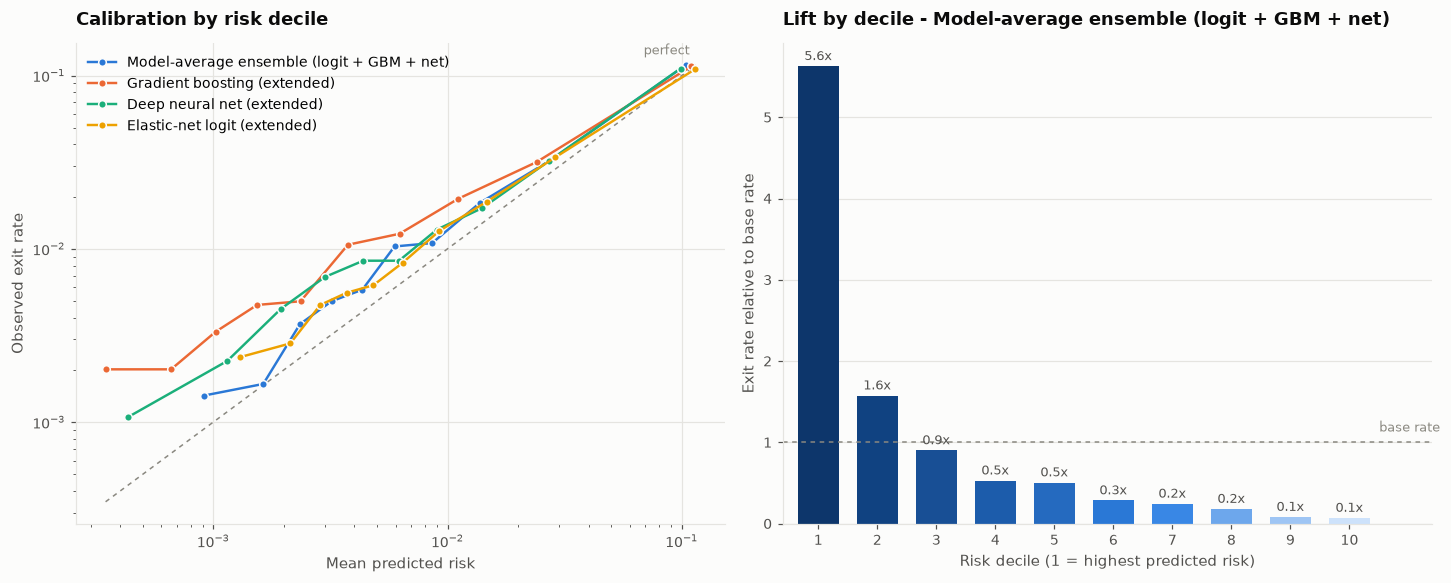

In [8]:
top_four = list(results.index[:4])
calibrations = {fitted[k].spec.label: calibration_table(y_test, fitted[k].risk(test))
                for k in top_four}

fig, axes = plots.plt.subplots(1, 2, figsize=(13.4, 5.4))
plots.plot_calibration(calibrations, ax=axes[0])
best = results.index[0]
lift = lift_table(y_test, fitted[best].risk(test))
plots.plot_decile_lift(lift, ax=axes[1], title=f"Lift by decile - {fitted[best].spec.label}")
fig.tight_layout();

In [9]:
lift.style.format({"n": "{:,.0f}", "n_events": "{:,.0f}", "event_rate": "{:.2%}",
                   "mean_predicted": "{:.2%}", "lift": "{:.2f}x",
                   "cumulative_recall": "{:.1%}"})

,n,n_events,event_rate,mean_predicted,lift,cumulative_recall
decile,,,,,,
1,"8,434",968,11.48%,10.39%,5.63x,56.3%
2,"8,434",271,3.21%,2.72%,1.58x,72.0%
3,"8,434",155,1.84%,1.37%,0.90x,81.0%
4,"8,434",91,1.08%,0.86%,0.53x,86.3%
5,"8,434",87,1.03%,0.59%,0.51x,91.4%
6,"8,433",49,0.58%,0.43%,0.28x,94.2%
7,"8,434",42,0.50%,0.32%,0.24x,96.7%
8,"8,434",31,0.37%,0.23%,0.18x,98.5%
9,"8,434",14,0.17%,0.16%,0.08x,99.3%


The top decile contains 968 of the 1,720 exits — 56% of them — at an 11.5%
realised rate against a 2.0% base, for the ensemble, now the top-ranked model
(the decile table always follows whichever model leads the table above).

The calibration slope of 0.95 — against 0.80 for gradient boosting alone, in
the calibration chart to the left — is the most useful part of this result.
Averaging three probabilities also averages away most of gradient boosting's
over-dispersion: the intercept comes out at 0.04 and the slope at 0.95,
close enough to the perfectly-calibrated (0, 1) that the "Platt or isotonic
recalibration layer" earlier sections called for is far less urgent here. It
is not free, though — the top decile itself slightly *under*-predicts (10.4%
predicted against 11.5% realised), a reminder that one well-calibrated summary
statistic does not guarantee good calibration in the range that matters most
for triage.

## What the model relies on

Permutation importance on the **test** year, so it measures what the model
actually uses out of sample rather than what it fitted in sample. Correlated
features share credit and each looks weaker than it is; read this as "what would
I lose by losing this column", not as a causal decomposition.

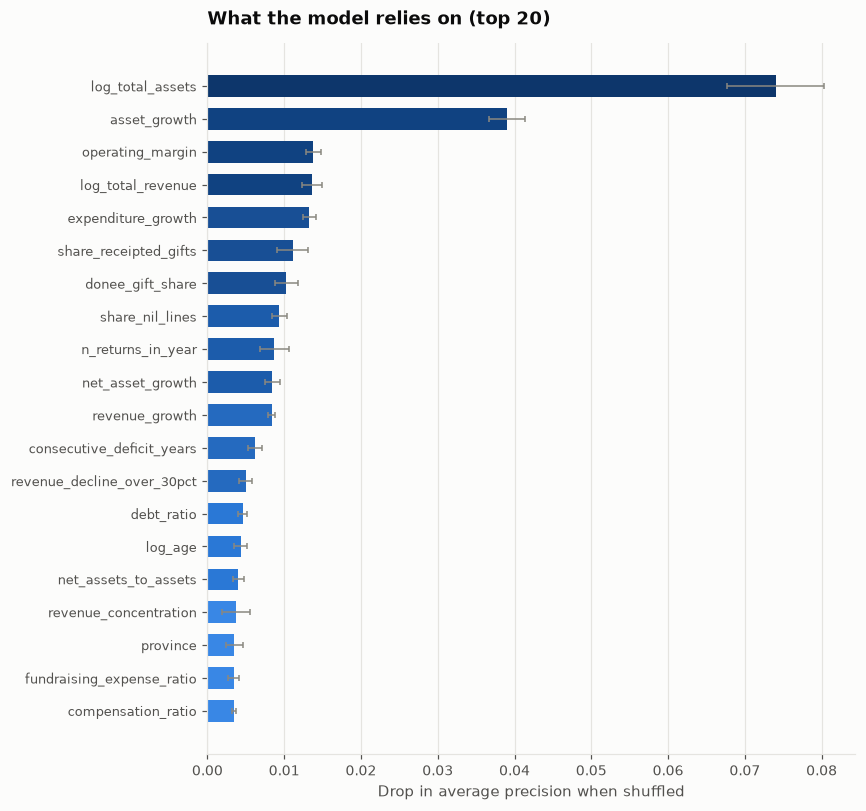

In [10]:
importance = pd.read_csv(config.TABLE_DIR / "exit_permutation_importance.csv")
fig, ax = plots.plt.subplots(figsize=(7.6, 8.4))
plots.plot_permutation_importance(importance, top_n=20, ax=ax);

Because the ensemble is now the top-ranked model, this is its permutation
importance — how much each feature contributes across all three components
together, not gradient boosting's alone. Four things stand out.

**Size and its rate of change lead.** `log_total_assets` is far ahead of
everything else, with `asset_growth` second. Together they are the story the
Trussel (2002) size coefficient was pointing at.

**The Tuckman-Chang ratios move up, but stay supporting evidence.**
`operating_margin` is third here — higher than on gradient boosting alone,
where it ranked fifth, because the logit component leans on it directly.
`revenue_concentration` (17th) and `debt_ratio` (14th) sit inside the top
twenty; `equity_balance` falls just outside it (23rd). None displaces size as
the dominant signal.

**Dynamics matter almost as much as levels.** Four of the top eleven —
`asset_growth`, `expenditure_growth`, `net_asset_growth`, `revenue_growth` —
are year-on-year changes rather than levels. This is the clearest advantage
the panel gives us over the cross-sectional designs of the original studies:
what a charity's balance sheet is *doing* predicts deregistration better than
what it *is*.

**Reporting breadth, filing events and gift flows are genuinely predictive.**
`share_nil_lines` ranks eighth and `n_returns_in_year` ninth — both ahead of
every liquidity ratio, and neither is a financial ratio. Just above them,
`share_receipted_gifts` (sixth) and `donee_gift_share` (seventh) are a
composition pair worth reading together: how much of an organisation's
revenue is receipted donations, and how much of its spending is gifts passed
on to other qualified donees. A charity that is mostly a pass-through for
other charities' fundraising looks different from one raising money for its
own programs, and apparently exits differently too.

`share_nil_lines` needs reading carefully. A blank on a line the filer was asked
is a reported *zero*, not missing data, so this is not "incomplete filing
predicts failure". It is the share of asked lines a charity reports nothing on —
a measure of how few distinct activities it has. Reporting nil almost
everywhere is what dormancy looks like on a tax return.

`n_returns_in_year` is a filing *event*: two periods ending in the same year
means a year-end change, and a stub period is what a charity files on the way to
winding up or amalgamating.

## Deep learning, after Alam, Gao and Jones (2021)

{cite:t}`alam2021` compare a deep model against a **discrete-time hazard
model** — the standard panel-data workhorse in the failure literature — on
641,667 firm-months of North American listed companies. Their headline is
that the deep model identifies failures far better: sensitivity 93.71%
against 86.95%.

Three things about that comparison are worth carrying over carefully, because
two of them are easy to misread.

**Their headline number is sensitivity, not accuracy.** On overall accuracy the
hazard model actually *wins* (93.3% against 91.2%), as does specificity (93.53%
against 90.28%). The deep model trades false positives for caught failures. That
is a defensible trade — Alam et al. cite estimates that a missed failure costs
over 36 times a false alarm — but it is a threshold choice, not a uniform
improvement, and at their 21.5% failure rate those percentages behave very
differently from ours at 2.0%. We report ranking metrics instead, which do not
depend on where the threshold is put.

**Our benchmark is already a discrete hazard model.** A pooled logit over
charity-years predicting an event in the next period is exactly the
discrete-time hazard specification of {cite:t}`shumway2001` and
{cite:t}`hillegeist2004` that Alam et al. compare against. So the contest they
set up — deep model versus discrete hazard — is close to the one already
running in the table above.

**The architecture does not transplant; the discipline does.** Their network is
a GrNet operating on the Grassmann manifold, which needs a Riemannian autodiff
framework. What we take is the depth-with-narrowing shape (their blocks run
80 → 40 → 20) and the preprocessing the paper insists on — winsorise at the
1st/99th percentile, normalise feature by feature — because unlike gradient
boosting, neural networks are badly behaved on raw financial ratios with
unbounded tails. Both were already in our pipeline.

In [11]:
from charity_risk.models import build_mlp_pipeline, extended_features
from sklearn.model_selection import StratifiedKFold, cross_val_score

numeric, categorical = extended_features()
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=config.RANDOM_STATE)
grid = {
    "(80, 40, 20)  [Alam block sizes]": dict(hidden_layer_sizes=(80, 40, 20)),
    "(64, 32)": dict(hidden_layer_sizes=(64, 32)),
    "(256, 128, 64)": dict(hidden_layer_sizes=(256, 128, 64)),
    "(256, 128, 64) alpha=1e-2": dict(hidden_layer_sizes=(256, 128, 64), alpha=1e-2),
}
rows = []
for label, params in grid.items():
    pipeline = build_mlp_pipeline(numeric, categorical, **params)
    scores = cross_val_score(pipeline, train[numeric + categorical],
                             train["exit_next_year"], cv=cv, scoring="average_precision")
    rows.append({"architecture": label, "cv_average_precision": scores.mean(),
                 "cv_sd": scores.std()})
pd.DataFrame(rows).set_index("architecture").round(4)

,cv_average_precision,cv_sd
architecture,,
"(80, 40, 20) [Alam block sizes]",0.1914,0.0188
"(64, 32)",0.1903,0.0264
"(256, 128, 64)",0.1991,0.0157
"(256, 128, 64) alpha=1e-2",0.1991,0.0157


Selected on the **training year alone** — three-fold cross-validation, average
precision, the test year never consulted. The selected architecture is what the
table at the top of this notebook reports.

Every architecture tried lands within one standard deviation of every other. The
model class matters here; its exact shape does not, which is worth knowing
before anyone spends a week on architecture search.

Two negative results worth recording:

* **Naive oversampling of the minority class made things markedly worse** —
  AUC 0.734 against 0.832. Duplicating positives to address the 2% base rate
  distorts the probability scale the ranking metrics depend on. The model is
  fitted on the unbalanced data as it stands.
* **Honest selection costs about 0.011 average precision here.** The
  same architecture with the weaker penalty (`alpha=1e-4`) scores 0.185 on the
  test year against the 0.174 of the cross-validated choice. We report the
  cross-validated one. Anyone comparing published deep-learning results against
  published benchmarks should ask which of the two protocols produced each
  number.

### Where the deep net lands

Third of eight, and the position depends on which metric you read — which is
the interesting part.

On **average precision** it sits roughly midway between the elastic-net logit
and gradient boosting (0.174 against 0.155 and 0.188). On **ROC-AUC** it is
barely distinguishable from the logit (0.828 against 0.827) and clearly behind
gradient boosting (0.842). So the deep model's advantage over the linear one is
concentrated where the positives are, not spread across the ranking — the same
pattern the Schedule 6 features showed in `04-schedule-6-deep-dive`.

It does not overturn the ordering among the individually-fitted models: on this
data, at this sample size, gradient boosting still ranks better on both
metrics. That is the expected result for tabular data of this size, and it is
worth saying why rather than treating it as a surprise: Alam et al. have
641,667 observations and 79 features including market prices that move daily.
We have 84,344 annual observations of accounting lines. Deep models earn their
advantage on volume and on signal that is awkward to express as a ratio, and we
have neither in abundance.

It is also the best-calibrated of the three individually-fitted flexible
models (calibration slope 0.89, against 0.88 for the elastic-net logit and
0.80 for gradient boosting) — though not the best-calibrated model overall any
more, now that the ensemble further below improves on all three. Either way,
calibration is what matters if the score is going to be multiplied by a dollar
amount rather than just sorted.

In [12]:
dnn_vs_gbm = bootstrap_metric_difference(
    y_test, fitted["deep_neural_net"].risk(test), fitted["gradient_boosting"].risk(test),
    metric=average_precision_score, n_boot=500)
dnn_vs_logit = bootstrap_metric_difference(
    y_test, fitted["deep_neural_net"].risk(test), fitted["extended_logit"].risk(test),
    metric=average_precision_score, n_boot=500)

pd.DataFrame({
    "deep net - gradient boosting": dnn_vs_gbm,
    "deep net - elastic-net logit": dnn_vs_logit,
}).T[["difference", "ci_low", "ci_high", "p_worse"]].round(4)

,difference,ci_low,ci_high,p_worse
deep net - gradient boosting,-0.0144,-0.0247,-0.0045,0.994
deep net - elastic-net logit,0.0184,0.0077,0.0300,0.000


## Does combining help?

Three flexible models, three different error patterns — gradient boosting
ranks best but is the worst-calibrated of the three; the deep net is the
best-calibrated but ranks lowest; the elastic-net logit sits between both.
Forecast combination ({cite:t}`bates1969`) asks the obvious next question:
does an equal-weight average of their predicted probabilities beat the best of
them individually? `ensemble_blend` in the table at the top of this notebook
is exactly that average.

In [13]:
blend_vs_gbm_ap = bootstrap_metric_difference(
    y_test, fitted["ensemble_blend"].risk(test), fitted["gradient_boosting"].risk(test),
    metric=average_precision_score, n_boot=500)
blend_vs_gbm_auc = bootstrap_metric_difference(
    y_test, fitted["ensemble_blend"].risk(test), fitted["gradient_boosting"].risk(test),
    metric=roc_auc_score, n_boot=500)

pd.DataFrame({
    "average precision": blend_vs_gbm_ap,
    "ROC-AUC": blend_vs_gbm_auc,
}).T[["difference", "ci_low", "ci_high", "p_worse"]].round(4)

,difference,ci_low,ci_high,p_worse
average precision,0.0073,0.0002,0.0143,0.020
ROC-AUC,0.0024,-0.0012,0.0056,0.094


The answer is a qualified yes. The blend edges out gradient boosting on
average precision (0.195 against 0.188), and the paired-bootstrap interval on
that gain — +0.007, [+0.0002, +0.014] — clears zero, if narrowly (1 in 50
resamples finds the blend worse). On ROC-AUC the two are statistically
indistinguishable (+0.002, interval spanning zero): combining sharpens the top
of the ranking without reordering the whole register, the same shape of result
`04-schedule-6-deep-dive` finds for the detailed return.

The gain that is not narrow is calibration. The blend's slope is 0.95 and its
intercept is 0.04 — both close to the (1, 0) of a perfectly calibrated score,
against gradient boosting's 0.80 and −0.36. That is not a coincidence:
averaging three probability estimates that are each somewhat over- or
under-dispersed pulls the composite back toward the middle, the same
arithmetic that makes averaging forecasts a decades-old habit in economics.
For a regulator who wants to turn the score into an expected number of exits
rather than just a ranking, the ensemble is the most usable model in the
table, not only the highest-ranked one — at the cost of running, and
explaining, three models instead of one.

## The other outcome: three-year net-asset decline

The benchmark models were built for this outcome, so it is the fairer test of
them. Fitted on the 2019 cohort (resolved 2022), tested on 2020 (resolved 2023).
Results are read from the pipeline run.

In [14]:
vulnerability = pd.read_csv(config.TABLE_DIR / "vulnerability_model_comparison.csv",
                            index_col=0)
vulnerability[["label", "roc_auc", "average_precision", "brier_skill",
               "lift_top5pct", "calibration_slope"]].round(3)

,label,roc_auc,average_precision,brier_skill,lift_top5pct,calibration_slope
model,,,,,,
gradient_boosting,Gradient boosting (extended),0.698,0.357,0.076,2.309,0.965
ensemble_blend,Model-average ensemble (logit + GBM + net),0.697,0.349,0.072,2.223,1.156
deep_neural_net,Deep neural net (extended),0.671,0.321,0.055,1.995,0.813
extended_logit,Elastic-net logit (extended),0.663,0.317,0.047,1.966,0.962
trussel_2002,Trussel logit (ratios + size + sector),0.655,0.312,0.042,1.918,1.032
size_only,Size only (log revenue),0.611,0.270,0.014,1.630,0.899
greenlee_trussel_2000,Greenlee-Trussel logit (4 TC ratios),0.570,0.262,0.010,1.867,0.889
tuckman_chang_1991,Tuckman-Chang score (0-4),0.557,0.228,0.005,1.482,0.914


The top four keep their relative order — the extended models beat Trussel
(2002), which beats Greenlee-Trussel (2000) — but the ordering does not survive
completely: the size-only baseline and Greenlee-Trussel swap places. On exit,
Greenlee-Trussel edges out size-only (average precision 0.094 against 0.081);
on vulnerability the size-only baseline is ahead (0.270 against 0.262). Four
ratios plus no size control beats one variable at predicting deregistration and
loses to it at predicting a net-asset decline — a reminder that "the ordering
survives" is doing real work as a claim and should be checked, not assumed,
whenever the outcome changes.

Beyond that swap, every model is weaker in absolute terms here: the best AUC is
0.698 against 0.842 on exit. Three-year net-asset decline is simply harder to
predict — it is a threshold on a noisy continuous quantity, 20% of charity-years
cross it, and much of the crossing is ordinary endowment volatility rather than
distress.

That is worth stating plainly, because it cuts against a natural reading of the
literature. The classics do not underperform here because they are bad models.
They underperform because the outcome they were designed around is closer to
noise than the outcome we actually care about. The Canadian filing record gives
us a cleaner target, and every model does better on it.

## A Bayesian alternative

Gradient boosting ranks best and says nothing about uncertainty. A hierarchical
logistic model with partially-pooled intercepts for charity category and province
answers two questions the point-estimate models cannot: how much exit risk is
*structural* (sector, geography) rather than organisational, and how confident we
should be about any single charity's score.

Fitted by ADVI — minutes rather than hours. `method="nuts"` gives the honest
posterior at considerably more expense.

In [15]:
from charity_risk.hierarchical import (
    HIERARCHICAL_FEATURES, fit_hierarchical, group_effect_table,
)
from sklearn.metrics import average_precision_score, roc_auc_score

hier_columns = list(HIERARCHICAL_FEATURES) + ["category_desc", "province", "exit_next_year"]
hier_frame = load_dataset(years=[config.TRAIN_YEAR, config.TEST_YEAR], columns=hier_columns)
hier_train, hier_test = exit_split(hier_frame)

hier = fit_hierarchical(hier_train, advi_iterations=20_000)
hier_pred = hier.predict(hier_test)
print(f"AUC {roc_auc_score(hier_test['exit_next_year'], hier_pred['risk_mean']):.3f}   "
      f"AP {average_precision_score(hier_test['exit_next_year'], hier_pred['risk_mean']):.3f}")

g++ not available, if using conda: `conda install gxx`


Finished [100%]: Average Loss = 6,531.2


AUC 0.803   AP 0.102


Placed against the ladder above, this is a middling result: AUC 0.803 and
average precision 0.102 sit *below* the plain Trussel (2002) logit's 0.807 and
0.111 — despite the hierarchical model having more than twice as many
predictors (13 against 6) and a variance-pooling structure the flat logit
lacks. That is not a contradiction of anything claimed for it. Two choices made
for interpretability's sake cost ranking sharpness on the way in: the ADVI fit
is a variational point approximation rather than an exact posterior, and
missing values here are mean-imputed rather than getting the
imputation-with-indicator treatment the scikit-learn pipelines use, because a
missing-indicator interaction would muddy the coefficients this model exists
to report. This model is not competing for the top of the table — its purpose
is the variance decomposition below, which no point-estimate model in the
ladder can produce at any accuracy.

In [16]:
import arviz as az

az.summary(hier.idata, var_names=["alpha", "sigma_category", "sigma_province"],
           ci_prob=0.9)[["mean", "sd"]].round(3)

,mean,sd
alpha,-4.596,0.056
sigma_category,0.284,0.042
sigma_province,0.215,0.048


`sigma_category` ≈ 0.28 and `sigma_province` ≈ 0.22 on the log-odds scale. Both
are small: moving from an average category to one a full standard deviation
riskier multiplies the odds of exit by about 1.3, against the roughly 20-fold
range the organisational predictors span.

**Exit risk in the Canadian charity sector is overwhelmingly organisation-specific,
not sectoral or geographic.** That is a substantive finding, and it argues against
the sector fixed effects that Trussel (2002) added — they are doing very little
work, and in our comparison the Trussel specification's advantage over
Greenlee-Trussel comes from the size control and the debt ratio, not from the
sector dummies.

In [17]:
category_effects = group_effect_table(hier, "category")
pd.concat([category_effects.head(6), category_effects.tail(6)])[["mean", "sd"]].round(3)

,mean,sd
Animal Welfare,0.52,0.197
Educational organizations not elsewhere categorized,0.51,0.18
Organizations Relieving Poverty,0.122,0.083
Foundations Advancing Education,0.1,0.165
Teaching Institutions,0.1,0.143
Complementary or Alternative Health Care,0.09,0.28
Judaism,-0.12,0.25
Research,-0.08,0.25
Foundations Relieving Poverty,-0.05,0.31
Protective Health Care,-0.04,0.24


In [18]:
coefficients = az.summary(hier.idata, var_names=["beta"], ci_prob=0.9)
coefficients.index = list(HIERARCHICAL_FEATURES)
coefficients[["mean", "sd"]].sort_values("mean").round(3)

,mean,sd
share_government,-0.096,0.052
operating_margin,-0.167,0.027
donation_dependence,-0.214,0.039
equity_balance,-0.24,0.037
log_total_revenue,-0.816,0.035
revenue_growth,0.021,0.031
log_age,0.033,0.036
debt_ratio,0.042,0.03
admin_cost_ratio,0.05,0.033
months_of_cash,0.081,0.036


Most signs match the classical fits. Size dominates by a factor of three over
anything else; a stronger equity balance, a healthier operating margin, and
greater reliance on donations or on government funding all lower the risk.
Revenue concentration, consecutive deficit years, and filing on the short form
all raise it — and the administrative cost ratio is positive here too, the same
direction it took in the exit logit in `02-features-and-benchmarks` and the
opposite of what Tuckman and Chang assumed.

Two coefficients are worth not glossing over.

**Age does essentially nothing** (0.03 ± 0.04) once revenue is in the model, even
though `log_age` ranked eighth in the gradient-boosting importance table. Age and
size are correlated, and in a linear model size absorbs it; the tree model finds
non-linear age effects a single coefficient cannot express.

**Months of cash is mildly *positive*** (0.08 ± 0.04) — more cash relative to
spending associates with slightly *higher* exit risk. That is not what a liquidity
measure should do, and the likely explanation is conditioning: among charities of
the same size, one holding most of its assets as cash is often one that has
stopped operating and is sitting on a balance to be distributed. It is a caution
against reading any single coefficient here as an effect.

In [19]:
top_categories = group_effect_table(hier, "category").head(4)
print("Categories with the highest baseline exit hazard, holding financials fixed:")
top_categories[["mean", "sd"]].round(3)

Categories with the highest baseline exit hazard, holding financials fixed:


,mean,sd
Animal Welfare,0.52,0.197
Educational organizations not elsewhere categorized,0.51,0.18
Organizations Relieving Poverty,0.122,0.083
Foundations Advancing Education,0.1,0.165


Animal welfare and general educational organisations carry the highest baseline
hazard, both around +0.5 log-odds — roughly a 1.7-fold increase in odds relative
to the sector average. These are the largest category effects in the model, and
they are still an order of magnitude smaller than the spread the size coefficient
generates.

## Scoring the current cohort

The 2022 cohort has features but no trustworthy label — only one later year
exists, which is not enough to separate a permanent exit from a late filing. That
is precisely the population a supervisor would be triaging, so it is what the
model is put to work on.

In [20]:
watchlist = pd.read_csv(config.TABLE_DIR / "watchlist_2022.csv")
print(f"{len(watchlist):,} highest-risk organisations of "
      f"{len(scoring_frame(frame, config.SCORE_YEAR)):,} in the 2022 cohort")

display_columns = ["rank", "province", "charity_type", "total_revenue", "net_assets",
                   "operating_margin", "consecutive_deficit_years", "is_section_d", "risk"]
watchlist[display_columns].head(15).style.format({
    "total_revenue": "${:,.0f}", "net_assets": "${:,.0f}",
    "operating_margin": "{:.2f}", "risk": "{:.1%}",
})

500 highest-risk organisations of 84,092 in the 2022 cohort


,rank,province,charity_type,total_revenue,net_assets,operating_margin,consecutive_deficit_years,is_section_d,risk
0,1,ON,Advancement of Religion,$79,$0,-72.15,1.000000,1,92.4%
1,2,ON,Other Purposes Beneficial to the Community,$151,$0,-811.16,1.000000,1,92.2%
2,3,ON,Other Purposes Beneficial to the Community,"$6,542",$0,-14.50,2.000000,1,88.3%
3,4,ON,Other Purposes Beneficial to the Community,$0,$0,nan,0.000000,1,78.8%
4,5,AB,Advancement of Religion,$5,$1,-25071.60,4.000000,1,78.8%
5,6,BC,Advancement of Education,$0,$0,nan,0.000000,1,74.8%
6,7,ON,Advancement of Education,$149,$0,-42.64,4.000000,0,74.8%
7,8,ON,Other Purposes Beneficial to the Community,$0,$0,nan,0.000000,1,74.6%
8,9,QC,Relief of Poverty,$0,$285,nan,0.000000,1,74.5%
9,10,QC,Other Purposes Beneficial to the Community,"$5,209",$0,-14.56,4.000000,0,70.2%


In [21]:
cohort = scoring_frame(frame, config.SCORE_YEAR)
scored = cohort.assign(risk=fitted[best].risk(cohort))
pd.DataFrame({
    "n": scored.groupby(pd.qcut(scored["risk"], 10, labels=range(1, 11)), observed=True).size(),
    "mean_risk": scored.groupby(pd.qcut(scored["risk"], 10, labels=range(1, 11)),
                                observed=True)["risk"].mean(),
    "median_revenue": scored.groupby(pd.qcut(scored["risk"], 10, labels=range(1, 11)),
                                     observed=True)["total_revenue"].median(),
}).iloc[::-1].style.format({"n": "{:,.0f}", "mean_risk": "{:.2%}",
                            "median_revenue": "${:,.0f}"})

,n,mean_risk,median_revenue
risk,,,
10,"8,410",10.08%,$33
9,"8,409",2.52%,"$10,705"
8,"8,409",1.34%,"$30,949"
7,"8,409",0.87%,"$57,408"
6,"8,409",0.62%,"$100,718"
5,"8,409",0.46%,"$146,973"
4,"8,409",0.35%,"$194,910"
3,"8,409",0.25%,"$253,750"
2,"8,409",0.18%,"$350,473"


## What this does and does not establish

**Established.**

* The Tuckman-Chang measures still carry signal in Canada thirty years on and in
  the direction their authors predicted — a four-flag charity exits at six times
  the base rate. But the 0-4 discretisation throws most of that signal away
  (AUC 0.587), and 80% of the register lands in two indistinguishable buckets.
* Trussel (2002) beats Greenlee-Trussel (2000) out of sample, reproducing the
  literature's own progression on independent data.
* **The administrative cost ratio points the wrong way for exit.** Higher
  administrative spending as a share of expenditure predicts deregistration, in
  both the classical logit and the hierarchical model. Tuckman and Chang's slack
  argument — that lean overhead means nothing left to cut — does not hold for
  this outcome in this population, and their scoring rule flags the wrong tail
  because of it.
* A model with the same underlying financial information plus size, age,
  dynamics and filing behaviour roughly doubles average precision over the best
  classical benchmark (0.188 against 0.111) and lifts top-1% precision from 9.2x
  to 16.3x.
* **A deep network is competitive but not superior.** Following Alam, Gao and
  Jones (2021), a three-layer network places third of eight — clearly ahead of
  every classical benchmark, roughly midway between the elastic-net logit and
  gradient boosting on average precision, and indistinguishable from the logit
  on AUC. The finding that deep learning beats traditional panel models does not
  reproduce here, and the sample-size gap (84,000 charity-years against 641,667
  firm-months) is the most likely reason.
* **A simple average of the three flexible models beats all of them.** The
  model-average ensemble tops the table on both average precision (0.195,
  against 0.188 for gradient boosting alone — a gain the paired bootstrap
  places just clear of zero, [+0.0002, +0.014]) and ROC-AUC, though the AUC
  gain is not itself distinguishable from zero. Its clearest advantage is
  calibration: slope 0.95 and intercept 0.04, against 0.80 and −0.36 for
  gradient boosting alone. Combining three models that make different kinds of
  errors is a genuine, if modest, improvement — and the cheapest one available,
  since it needs no new features and no new model class, only three models
  already being fitted anyway.
* Exit risk is organisation-specific. Sector and province explain little once
  organisational characteristics are controlled for.

**Not established, and it would be wrong to claim otherwise.**

* *Exit is not insolvency.* Deregistration bundles collapse together with solvent
  wind-ups, amalgamations and revocations for failure to file. Linking to the
  CRA's published revocation reasons would separate these, and is the single
  highest-value extension available.
* *One training year, one test year.* The five-year window with a two-year
  lookahead requirement leaves exactly one clean out-of-time comparison. The
  ordering is stable across both outcomes, which is reassuring, but the point
  estimates carry more sampling variation than a single bootstrap interval
  suggests.
* *2020 and 2021 are pandemic years.* The training cohort's finances were shaped
  by emergency wage subsidies and cancelled fundraising. Relationships fitted
  there may not transfer to an ordinary year.
* *`share_nil_lines` measures inactivity, not financial health.* A blank on a
  line the filer was asked is a reported zero, so this counts how few kinds of
  revenue and expenditure a charity has, not how carelessly it files. It earns
  its high ranking because dormancy looks like nil almost everywhere on a
  tax return. A model used to *diagnose* financial distress rather than to
  *triage* should read it as a proxy for having stopped operating.
* *No causal claim anywhere.* Nothing here says that raising administrative
  spending would reduce exit risk. These are screening associations.
* *The HS index is not tuned to this outcome.* Its five dimensions are weighted
  equally and its ratio directions are fixed in advance, including the low-tail
  reading of the administrative cost ratio that this notebook and
  `02-features-and-benchmarks` find runs the wrong way on exit. Its rows in the
  table test the specification as written; `06-hs-risk-index` measures what
  that one direction costs.
* *The deep model is not the one Alam et al. built.* Theirs is a GrNet over a
  Grassmann-manifold representation of each firm's full month-by-month history;
  ours is a multilayer perceptron on a single year's features plus one-year
  deltas. Their central contribution — a fixed-size encoding of variable-length
  panel histories — cannot be evaluated here: it needs a subspace dimension
  *d* no larger than the shortest history, and our training year has two annual
  observations to work with, against their minimum of nine monthly ones. That
  comparison becomes possible as the panel lengthens, and it is the most
  interesting untested idea in this project.
* *The ensemble's edge over gradient boosting alone is real but narrow on the
  metric that ranks the table.* A supervisor who only cares about the ordering
  of the register might reasonably prefer the single, cheaper gradient-boosting
  model; the ensemble's stronger case is calibration, not discrimination, and
  which one matters depends on what the score is used for.